# Проект для «Викишоп» с BERT

<div class="alert alert-info">
<font size="5"><b>Комментарий ревьюера</b></font>

Привет Вячеслав ещё раз! Меня зовут Марат, и я буду твоим ревьюером. Спешу сообщить что все ключевые этапы в работе выполнены,  с задачей тебе удалось справиться. По поводу обращения - в IT сфере принято общаться на «ты» :) Но, если привычней на «вы», дай знать. Как ревьюера моя задача помочь тебе в развитии, дав хорошие советы. Я внимательно посмотрю твой код, ознакомлюсь с твоими выводами и оставлю комментарии. Где то могу предложить небольшие исправление в коде, но ненавязчиво. Где потребуются уточнения, я оставлю много наводящих вопросов. Они помогут тебя с поиском верного решения.

Все мои комментарии размечены по цветам, для лучшего восприятия. 
    
<div class="alert alert-success">Зеленым цветом и словом «Успех» отмечены особо удачные и элегантные решения, которыми ты можешь гордиться. </div>
        
<div class="alert alert-warning">Желтым и значком словом «Совет», помечены решения у которых есть альтернативные решения, более оптимальные. Ты можешь найти их сразу и доработать проект, или отложить это на потом, для будущих проектах. Проект будет принят и без их доработки. </div>
        
<div class="alert alert-danger"> Красным цветом и значком словом «Ошибка» помечу твои решения, на которые стоит обратить внимание прежде всего. После их доработки проект будет принят. </div>
        
Залог успеха - работа сообща, взаимное уважение и работа в диалоге. Поэтому, помечай свои ответные комментарии на мои реплики заметным цветом или курсивом, так мне будет легче их отслеживать. Пожалуйста, не изменяй и не удаляй мои комментарии. Все это поможет выполнить повторную проверку быстрей.

</div>

Интернет-магазин «Викишоп» запускает новый сервис. Теперь пользователи могут редактировать и дополнять описания товаров, как в вики-сообществах. То есть клиенты предлагают свои правки и комментируют изменения других. Магазину нужен инструмент, который будет искать токсичные комментарии и отправлять их на модерацию.

Обучите модель классифицировать комментарии на позитивные и негативные. В вашем распоряжении набор данных с разметкой о токсичности правок.

Постройте модель со значением метрики качества *F1* не меньше 0.75.

**Инструкция по выполнению проекта**

1. Загрузите и подготовьте данные.
2. Обучите разные модели.
3. Сделайте выводы.

Для выполнения проекта применять *BERT* необязательно, но вы можете попробовать.

**Описание данных**

Данные находятся в файле `toxic_comments.csv`. Столбец *text* в нём содержит текст комментария, а *toxic* — целевой признак.

## 1. Загрузка данных

Объявим необходмые библиотеки, загрузим датафрейм и выведем основную информацию:

In [1]:
%matplotlib inline

import pandas as pd
import os
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import math
import shap

import ydata_profiling as pp
from ydata_profiling import ProfileReport

import nltk
from nltk.sentiment.vader import SentimentIntensityAnalyzer
from nltk.tokenize import word_tokenize, sent_tokenize

import torch
import torch.nn as nn
from torch.utils.data import DataLoader, Dataset

from transformers import AutoTokenizer, AutoModel, AdamW
from tqdm import tqdm

from sklearn.model_selection import train_test_split
from sklearn.metrics import f1_score, confusion_matrix
from sklearn.utils.class_weight import compute_class_weight
from sklearn.dummy import DummyClassifier
from sklearn.preprocessing import StandardScaler

In [2]:
print(torch.cuda.is_available())
if torch.cuda.is_available():
    print("GPU is available")
    print(torch.cuda.get_device_name(0)) # Выводит имя устройства GPU
else:
    print("GPU is not available")

In [3]:
device = torch . device ( "cuda:0" if torch . cuda . is_available () else "cpu" )
# Assuming that we are on a CUDA machine, this should print a CUDA device:
print ( device )

In [4]:
'''#! gdown #данные скрыты'''

In [5]:
pth_1 = '/content/toxic_comments.csv'
pth_2 = '/datasets/toxic_comments.csv'
pth_3 = 'toxic_comments.csv'

pd.set_option('display.max_columns', None)

if os.path.exists(pth_1):
    df_tweets = pd.read_csv(pth_1, index_col=[0])
    display(df_tweets.head())
    df_tweets.info()
elif os.path.exists(pth_2):
    df_tweets = pd.read_csv(pth_2, index_col=[0])
    display(df_tweets.head())
    df_tweets.info()
elif os.path.exists(pth_3):
    df_tweets = pd.read_csv(pth_3, index_col=[0])
    display(df_tweets.head())
    df_tweets.info()
else:
    print('Путь к датафрейму не найден')

##  EDA-aнализ

Детальнее изучим данные с помощью EDA.

#проведение EDA
pp.ProfileReport(df_tweets, vars={'num': {'low_categorical_threshold': 10}}, title="Отчет о данных", explorative=True)

#### Промежуточный вывод:

* пропуски в данных отсутствуют;
* заметим, что целевой параметр `toxic` имеет сильный дисбаланс - обычных фраз гораздо больше, чем "токсичных". Это необходимо учесть при разделении датасета на выборки.

In [7]:
# Загрузка необходимых ресурсов NLTK
try:
    nltk.data.find('tokenizers/punkt')
    nltk.data.find('sentiment/vader_lexicon')
except LookupError:
    print("Загрузка ресурсов NLTK...")
    nltk.download('punkt')
    nltk.download('vader_lexicon')
    print("Загрузка завершена.")

def analyze_text(text):
    """Анализирует текст и возвращает словарь характеристик."""
    try:
        sentences = sent_tokenize(text)
        words = word_tokenize(text)
        num_sentences = len(sentences)
        num_words = len(words)
        avg_word_length = sum(len(word) for word in words) / num_words if num_words > 0 else 0
        analyzer = SentimentIntensityAnalyzer()
        sentiment = analyzer.polarity_scores(text)
        return {
            'количество_предложений': num_sentences,
            'количество_слов': num_words,
            'средняя_длина_слова': avg_word_length,
            'настроение_составной': sentiment['compound'],
            'настроение_положительное': sentiment['pos'],
            'настроение_отрицательное': sentiment['neg'],
            'настроение_нейтральное': sentiment['neu']
        }
    except Exception as e:
        print(f"Ошибка при анализе текста: {e}")
        return {
            'количество_предложений': 0, 'количество_слов': 0, 'средняя_длина_слова': 0,
            'настроение_составной': 0, 'настроение_положительное': 0, 'настроение_отрицательное': 0,
            'настроение_нейтральное': 0
        }

def preprocess_df(df):
    """Добавляет вычисленные признаки в DataFrame."""
    try:
        df[['количество_предложений', 'количество_слов', 'средняя_длина_слова',
            'настроение_составной', 'настроение_положительное', 'настроение_отрицательное',
            'настроение_нейтральное']] = pd.DataFrame(df['text'].apply(analyze_text).tolist())
        return df
    except Exception as e:
        print(f"Ошибка при предобработке DataFrame: {e}")
        return None


In [8]:
try:
    df_processed = preprocess_df(df_tweets)
    if df_processed is not None:
        df_processed.to_csv("processed_tweets.csv", index=False)
        print("Обработанные данные сохранены в processed_tweets.csv")
    else:
        print("Ошибка при обработке данных.")
except Exception as e:
    print(f"Произошла ошибка: {e}")

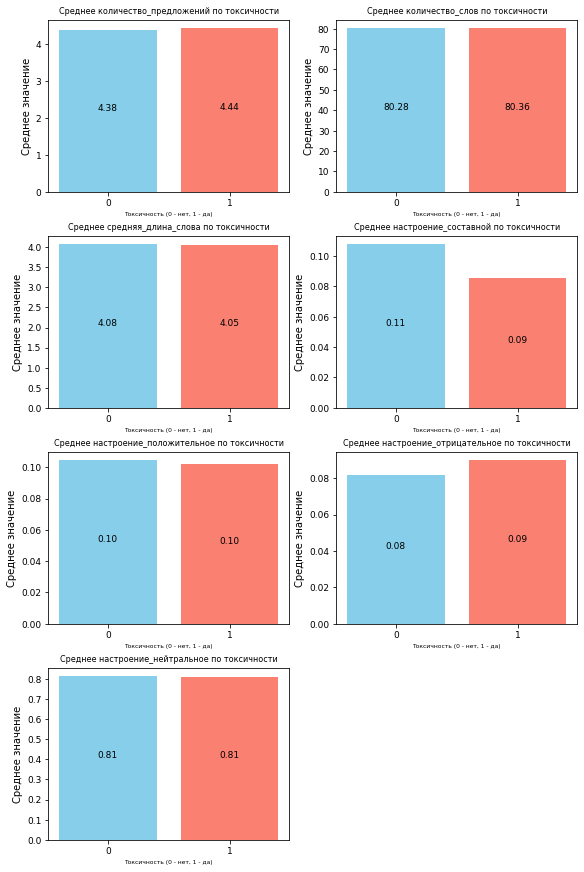

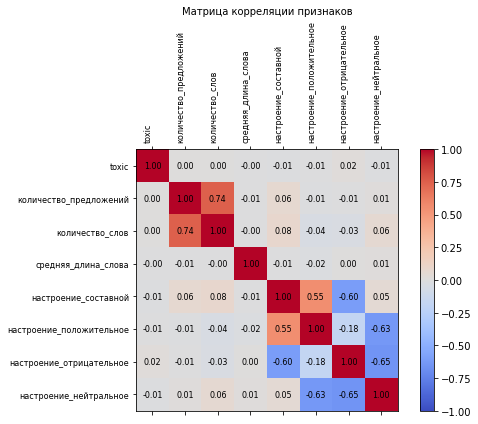

In [9]:
# Загрузка обработанных данных
df_tweets = pd.read_csv("processed_tweets.csv")

try:
    features = ['количество_предложений', 'количество_слов', 'средняя_длина_слова',
                'настроение_составной', 'настроение_положительное', 'настроение_отрицательное',
                'настроение_нейтральное']
    all_features = ['toxic'] + features

    if not all(f in df_tweets.columns for f in all_features):
        raise ValueError("Не все необходимые колонки найдены в DataFrame.")

    grouped = df_tweets.groupby('toxic').agg({feature: 'mean' for feature in features})

    num_plots = len(features)
    num_rows = math.ceil(num_plots / 2)
    num_cols = 2
    fig, axes = plt.subplots(num_rows, num_cols, figsize=(8, 3 * num_rows), constrained_layout=True)
    axes = axes.ravel()

    for i, feature in enumerate(features):
        rects = axes[i].bar([0, 1], grouped[feature], color=['skyblue', 'salmon'])
        axes[i].set_title(f'Среднее {feature} по токсичности', fontsize=8)
        axes[i].set_xlabel('Токсичность (0 - нет, 1 - да)', fontsize=6)
        axes[i].set_ylabel('Среднее значение')
        axes[i].tick_params(axis='x', rotation=0)
        axes[i].set_xticks([0, 1])
        axes[i].tick_params(labelsize=9)
        axes[i].bar_label(rects, labels=[f'{val:.2f}' for val in grouped[feature]], padding=3, label_type='center', fontsize=9)


    #Удаляем лишние подграфики
    for j in range(len(features), len(axes)):
        fig.delaxes(axes[j])


    correlation = df_tweets[all_features].corr()
    fig_corr, ax_corr = plt.subplots(figsize=(8, 6)) # Размер поменьше
    im = ax_corr.matshow(correlation, cmap=plt.cm.coolwarm, vmin=-1, vmax=1)
    ax_corr.set_xticks(range(len(correlation.columns)))
    ax_corr.set_xticklabels(correlation.columns, rotation=90, ha="right", fontsize=8)
    ax_corr.set_yticks(range(len(correlation.columns)))
    ax_corr.set_yticklabels(correlation.columns, fontsize=8)
    ax_corr.set_title('Матрица корреляции признаков', fontsize=10)
    fig_corr.colorbar(im, ax=ax_corr)
    for i in range(len(correlation.columns)):
        for j in range(len(correlation.columns)):
            ax_corr.text(j, i, f'{correlation.iloc[i, j]:.2f}', ha='center', va='center', color='black', fontsize=8)

    plt.tight_layout()
    plt.show()

except Exception as e:
    print(f"Произошла ошибка: {e}")

#### Промежуточный вывод:

Анализ текстовой части и дополнительно введённых признаков показал, что умеренной корреляцией с целевым параметром обладают `настроение_отрицательное`,  `настроение_нейтральное`, `настроение_составной`. Оставим эти признаки, остальные удалим.

In [10]:
df_tweets = df_tweets.drop(columns=['количество_предложений', 'количество_слов', \
                                    'средняя_длина_слова', 'настроение_положительное'])

## Подготовка данных к построению модели

Подготовим обучающую, валидационную и тестовую выборки.

In [11]:
# Стратифицированное разделение данных
train_df, test_df = train_test_split(
    df_tweets,
    test_size=0.2,  
    stratify=df_tweets['toxic'],
    random_state=42
)

train_df, val_df = train_test_split(
    train_df,
    test_size=0.2, 
    stratify=train_df['toxic'],
    random_state=42
)

print(f"Размер тренировочного набора: {len(train_df)}")
print(f"Размер валидационного набора: {len(val_df)}")
print(f"Размер тестового набора: {len(test_df)}")

## Создание константной модели

Для оценки модели BERT на адекватность создадим константную модель DummyClassifier, проверим её метрику.

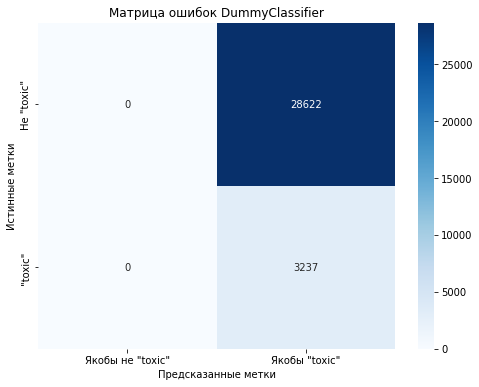

In [12]:
# Создание и обучение DummyClassifier
dummy_clf = DummyClassifier(strategy = 'constant', constant = 1)
dummy_clf.fit(train_df['text'], train_df['toxic'])

# Получение предсказаний
dummy_predictions = dummy_clf.predict(test_df['text'])

# Вычисление матрицы ошибок
cm_dummy = confusion_matrix(test_df['toxic'], dummy_predictions)

# Визуализация матрицы ошибок для DummyClassifier
plt.figure(figsize=(8, 6))
sns.heatmap(cm_dummy, annot=True, fmt='d', cmap='Blues', xticklabels=['Якобы не "toxic"', 'Якобы "toxic"'], yticklabels=['Не "toxic"', '"toxic"'])
plt.ylabel('Истинные метки')
plt.xlabel('Предсказанные метки')
plt.title('Матрица ошибок DummyClassifier')
plt.show()

# Вычисление метрики
f1 = f1_score(test_df['toxic'], dummy_predictions)

# Округление до двух знаков
f1 = round(f1, 3)

print(f'F1 Score: {f1}')

### Промежуточный вывод:

Выявлена метрика константной модели.

## Построение модели BERT

Для данного проекта воспользуемся предобученной моделью BERT, взятую из открытого источника https://habr.com/ru/articles/562064/. Модель `TinyBERT_General_4L_312D` на Hugging Face предоставляет предобученную модель BERT, оптимизированную для производительности на устройствах с ограниченными ресурсами.

Для лучшего результата дообучим её на тренировочной выборке.

Так как классы дисбалансированы, стандартная функция потерь может стать недостаточно информативной. Модель может просто "научиться" предсказывать наиболее распространенный класс, что приведет к низкой точности, несмотря на высокие результаты для преобладающего класса. Для этого введём веса классов.

In [13]:
# Загрузка токенизатора и модели
tokenizer = AutoTokenizer.from_pretrained("bert-base-uncased")
model = AutoModel.from_pretrained("bert-base-uncased")

# Проверка наличия GPU
if torch.cuda.is_available():
    model = model.cuda()  # Перемещаем модель на GPU, если он доступен

# Определение устройства (CPU или GPU)
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

In [14]:
batch_size = 100

def embed_in_batches(data, model, tokenizer, batch_size=100):
    """
    Генерирует эмбеддинги для текстовых данных, обрабатывая их батчами.

    :param data: Список текстов для векторизации.
    :param model: Обученная модель (например, BERT).
    :param tokenizer: Токенизатор, используемый для преобразования текста в токены.
    :param batch_size: Размер батча для обработки текстов.
    :return: Массив эмбеддингов.
    """
    embeddings = []

    # Находим максимальную длину токенизированной строки
    tokenized_lengths = [len(tokenizer.encode(text, truncation=True, add_special_tokens=True)) for text in data]
    max_length = max(tokenized_lengths)
    print(f"Максимальная длина токенизированной строки: {max_length}")

    # Токенизация с учетом max_length
    tokenized = [tokenizer.encode(text, truncation=True, max_length=max_length, return_tensors='np')[0] for text in data]
    max_len = max(len(i) for i in tokenized)

    padded = np.array([i.tolist() + [0] * (max_len - len(i)) for i in tokenized])
    attention_mask = np.where(padded != 0, 1, 0)

    # Обработка батчей
    for i in tqdm(range(0, len(data), batch_size), desc="Generating Embeddings"):
        # Формируем батч
        batch_padded_texts = padded[i:i + batch_size]
        batch_attention_mask = attention_mask[i:i + batch_size]

        # Переводим в тензоры
        input_ids = torch.tensor(batch_padded_texts).to(model.device)
        attention_mask_tensor = torch.tensor(batch_attention_mask).to(model.device)

        with torch.no_grad():
            # Передаем в модель
            model_output = model(input_ids=input_ids, attention_mask=attention_mask_tensor)

        # Выделяем эмбеддинги (CLS токен)
        batch_embeddings = model_output.last_hidden_state[:, 0, :]
        embeddings.append(batch_embeddings.cpu().numpy())

    return np.vstack(embeddings)  # Склеиваем список в один массив

In [15]:
# Преобразование текстов в эмбеддинги
train_embeddings = embed_in_batches(train_df['text'], model, tokenizer, batch_size)
val_embeddings = embed_in_batches(val_df['text'], model, tokenizer, batch_size) 
test_embeddings = embed_in_batches(test_df['text'], model, tokenizer, batch_size)

print()
print("Train embeddings shape:", train_embeddings.shape)
print("Val embeddings shape:", val_embeddings.shape) 
print("Test embeddings shape:", test_embeddings.shape)

In [16]:
# Обработка пропущенных значений (если есть)
for df in [train_df, val_df, test_df]:  # Обработка всех DataFrame
    for col in ['настроение_составной', 'настроение_отрицательное', 'настроение_нейтральное']:
        df.loc[:, col] = df.loc[:, col].fillna(df.loc[:, col].mean())

# Масштабируем дополнительные признаки (только fit на train_df, transform на других)
scaler = StandardScaler()
numerical_cols = ['настроение_составной', 'настроение_отрицательное', 'настроение_нейтральное']
train_df.loc[:, numerical_cols] = scaler.fit_transform(train_df[numerical_cols])
val_df.loc[:, numerical_cols] = scaler.transform(val_df[numerical_cols])
test_df.loc[:, numerical_cols] = scaler.transform(test_df[numerical_cols])


# --- Токенизация и создание датасета ---
tokenizer = AutoTokenizer.from_pretrained("bert-base-uncased", use_fast=True)

class ToxicDataset(Dataset):
    def __init__(self, texts, labels, additional_features, tokenizer):
        self.tokenizer = tokenizer
        self.texts = texts
        self.labels = labels
        self.additional_features = additional_features

    def __len__(self):
        return len(self.labels)

    def __getitem__(self, idx):
        text = self.texts[idx]
        label = torch.tensor(self.labels[idx], dtype=torch.long)
        additional_features = torch.tensor(self.additional_features[idx], dtype=torch.float32)
        encoding = self.tokenizer(text, truncation=True, padding='max_length', max_length=128, return_tensors='pt')
        input_ids = encoding['input_ids'].flatten()
        attention_mask = encoding['attention_mask'].flatten()
        return input_ids, attention_mask, label, additional_features

train_dataset = ToxicDataset(train_df['text'].values, train_df['toxic'].values, train_df[['настроение_составной', 'настроение_отрицательное', 'настроение_нейтральное']].values, tokenizer)
val_dataset = ToxicDataset(val_df['text'].values, val_df['toxic'].values, val_df[['настроение_составной', 'настроение_отрицательное', 'настроение_нейтральное']].values, tokenizer)
test_dataset = ToxicDataset(test_df['text'].values, test_df['toxic'].values, test_df[['настроение_составной', 'настроение_отрицательное', 'настроение_нейтральное']].values, tokenizer)


In [17]:
# --- Создание модели ---
try:
    model_bert = AutoModel.from_pretrained("bert-base-uncased")
    print("Модель BERT загружена успешно.")
except Exception as e:
    print(f"Ошибка при загрузке модели BERT: {e}")
    exit(1)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model_bert.to(device)
print(f"Модель перемещена на {device}.")

class ToxicClassifier(nn.Module):
    def __init__(self, bert_model, num_numerical_features=3):
        super().__init__()
        self.bert = bert_model
        self.fc_bert = nn.Linear(bert_model.config.hidden_size, 64)
        self.fc_additional = nn.Linear(num_numerical_features, 32)
        self.dropout = nn.Dropout(0.2)
        self.fc_combined = nn.Linear(64 + 32, 2)

    def forward(self, input_ids, attention_mask, additional_features):
        outputs = self.bert(input_ids=input_ids, attention_mask=attention_mask)
        bert_output = outputs.pooler_output
        bert_output = torch.relu(self.fc_bert(bert_output))
        additional_output = torch.relu(self.fc_additional(additional_features))
        combined_output = torch.cat((bert_output, additional_output), dim=1)
        combined_output = self.dropout(combined_output)
        final_output = self.fc_combined(combined_output)
        return final_output

classifier = ToxicClassifier(model_bert).to(device)

# Вычисляем веса классов
try:
    labels = train_df['toxic'].values
    class_weights = compute_class_weight('balanced', classes=np.unique(labels), y=labels)
    criterion = nn.CrossEntropyLoss(weight=torch.tensor(class_weights, dtype=torch.float32).to(device))
    print("Веса классов вычислены и критерий создан успешно.")
except Exception as e:
    print(f"Ошибка при вычислении весов классов: {e}")
    exit(1)

optimizer = torch.optim.AdamW(classifier.parameters(), lr=1e-5)
train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=32)

print("Подготовка к обучению завершена.")

In [18]:
# Обучение
train_losses = []
for epoch in range(3):
    classifier.train()
    running_loss = 0.0
    for input_ids, attention_mask, labels, additional_features in train_loader:
        input_ids = input_ids.to(device)
        attention_mask = attention_mask.to(device)
        labels = labels.to(device)
        additional_features = additional_features.to(device)
        optimizer.zero_grad()
        outputs = classifier(input_ids, attention_mask, additional_features)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()
        running_loss += loss.item()

    train_loss = running_loss / len(train_loader)
    train_losses.append(train_loss)
    print(f'Epoch {epoch + 1}, Loss: {train_loss:.4f}')


In [19]:
# Валидация
classifier.eval()
all_preds = []
all_labels = []
with torch.no_grad():
    for input_ids, attention_mask, labels, additional_features in val_loader:
        input_ids = input_ids.to(device)
        attention_mask = attention_mask.to(device)
        labels = labels.to(device)
        additional_features = additional_features.to(device)
        outputs = classifier(input_ids, attention_mask, additional_features)
        _, preds = torch.max(outputs, 1)
        all_preds.extend(preds.cpu().numpy())
        all_labels.extend(labels.cpu().numpy())

val_f1 = f1_score(all_labels, all_preds)
print(f'Val F1: {val_f1:.3f}')

In [24]:
# Тестирование
classifier.eval()
all_preds = []
all_labels = []

test_loader = DataLoader(test_dataset, batch_size=32, shuffle=False)

with torch.no_grad():
    for input_ids, attention_mask, labels, additional_features in test_loader:
        input_ids = input_ids.to(device)
        attention_mask = attention_mask.to(device)
        labels = labels.to(device)
        additional_features = additional_features.float().to(device)
        outputs = classifier(input_ids, attention_mask, additional_features)
        _, preds = torch.max(outputs, 1)
        all_preds.extend(preds.cpu().numpy())
        all_labels.extend(labels.cpu().numpy())

test_f1 = f1_score(all_labels, all_preds)
print(f'Test F1: {test_f1:.2f}')

### Промежуточный вывод:

Модель справилась с задачей: метрика F1-score на тестовой выборке выше необходимой.

## "Матрица ошибок"

Построим график "Матрица ошибок", наглядно показывающий разницу между действительными и предсказанными вероятностями модели.

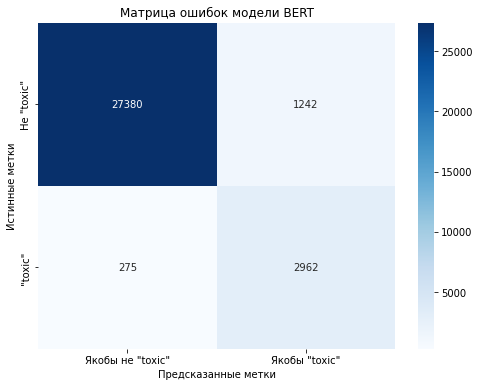

In [25]:
# Вычисление матрицы ошибок
cm = confusion_matrix(all_labels, all_preds)

# Визуализация матрицы ошибок
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=['Якобы не "toxic"', 'Якобы "toxic"'], yticklabels=['Не "toxic"', '"toxic"'])
plt.ylabel('Истинные метки')
plt.xlabel('Предсказанные метки')
plt.title('Матрица ошибок модели BERT')
plt.show()

### Промежуточный вывод:

По матрице ошибок видно, что модель хорошо предсказывает нетоксичные комментарии. Однако, если заказчику критически важно не пропустить токсичные комментарии, необходимо добавить в датасет больше токсичных примеров, т.к. модель выдаёт много ложноотрицательных прогнозов (~25% от общего количества токсичных комментариев в тестовой выборке). Либо снижать порог вероятности в ущерб метрике

## Общий вывод:

Интернет-магазин «Викишоп» запускает новый сервис. Теперь пользователи могут редактировать и дополнять описания товаров, как в вики-сообществах. То есть клиенты предлагают свои правки и комментируют изменения других. Магазину нужен инструмент, который будет искать токсичные комментарии и отправлять их на модерацию.

**Задачи проекта:**

1. Обучите модель классифицировать комментарии на позитивные и негативные. В вашем распоряжении набор данных с разметкой о токсичности правок.
2. Постройте модель со значением метрики качества *F1* не меньше 0.75.

**Инструкция по выполнению проекта**

1. Загрузите и подготовьте данные.
2. Обучите разные модели.
3. Сделайте выводы.

Для выполнения проекта применять *BERT* необязательно, но вы можете попробовать.

**Описание данных**

Данные находятся в файле `toxic_comments.csv`. Столбец *text* в нём содержит текст комментария, а *toxic* — целевой признак.

**В ходе EDA-анализа выявлено:**

* пропуски в данных отсутствуют;
* целевой параметр `toxic` имеет сильный дисбаланс - обычных фраз гораздо больше, чем "токсичных".

Анализ текстовой части и дополнительно введённых признаков показал, что умеренной корреляцией с целевым параметром обладают `настроение_отрицательное`,  `настроение_нейтральное`, `настроение_составной`. Эти признаки оставлены для обучения.

Для оценки модели BERT на адекватность создана константная модель DummyClassifier.

Для данного проекта была использована предобученная моделью BERT, взятая из открытого источника https://habr.com/ru/articles/562064/.

Для лучшего результата она была дообучена на тренировочной выборке.

Так как классы дисбалансированы, стандартная функция потерь может стать недостаточно информативной. Модель может просто "научиться" предсказывать наиболее распространенный класс, что приведет к низкой точности, несмотря на высокие результаты для преобладающего класса. Для этого введены веса классов.

**Модель справилась с задачей:** метрика F1-score на тестовой выборке выше необходимой.

По матрице ошибок видно, что модель хорошо предсказывает нетоксичные комментарии. Однако, **если заказчику критически важно не пропустить токсичные комментарии,** необходимо добавить в датасет больше токсичных примеров, т.к. модель выдаёт много ложноотрицательных прогнозов (~25% от общего количества токсичных комментариев в тестовой выборке). Либо снижать порог вероятности в ущерб метрике